In [8]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp, wasserstein_distance, entropy, chisquare
from itertools import combinations
import matplotlib.pyplot as plt


# 1. CSV-Dateien einlesen (Pfad zu realen und synthetischen Daten anpassen)
real_path = "../../data/data_for_CTGAN/CTGAN_basedata.csv"
syn_path1 = "../../data/synthetic_result_data/536_synthetic_train_data.csv"
syn_path2 = "../../data/synthetic_result_data/536_synthetic.csv"
syn_path3 = "../../data/synthetic_result_data/new_synthetic_data.csv"

df_real = pd.read_csv(real_path)
df_syn1 = pd.read_csv(syn_path1)
df_syn2 = pd.read_csv(syn_path2)
df_syn3 = pd.read_csv(syn_path3)


In [9]:
def compute_subscores(original: pd.DataFrame, synthetic: pd.DataFrame, alpha_kl=1.0, mmd_gamma=1.0, weights=None):
    """
    Compute Statistical Similarity Score (SSS) subscores for each feature and overall score.
    Returns a dict with per-feature subscores and the overall SSS.
    """
    def compute_mmd(x, y, gamma):
        """Compute unbiased MMD with RBF kernel, returning a scalar."""
        X = x.values.flatten()
        Y = y.values.flatten()
        Kxx = np.exp(-gamma * (X[:, None] - X[None, :])**2)
        Kyy = np.exp(-gamma * (Y[:, None] - Y[None, :])**2)
        Kxy = np.exp(-gamma * (X[:, None] - Y[None, :])**2)
        n, m = len(X), len(Y)
        mmd2 = (
            (Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.sum() / (n * m)
        )
        return np.sqrt(max(mmd2, 0))

    # Sprechende Metriknamen
    metric_names = ['mean','median','variance','ks','chi2','wasserstein','mmd','kl','coverage']

    if weights is None:
        # Default: gleichmäßige Verteilung
        weights = {name: 1/len(metric_names) for name in metric_names}

    results = {}
    feature_scores = []

    for col in original.columns:
        o = original[col]
        s = synthetic[col]
        subscores = {}

        if pd.api.types.is_numeric_dtype(o):
            R = o.max() - o.min()
            delta_mean = abs(o.mean() - s.mean())
            subscores['mean'] = max(0, 1 - delta_mean / R) if R > 0 else 1.0

            delta_median = abs(o.median() - s.median())
            subscores['median'] = max(0, 1 - delta_median / R) if R > 0 else 1.0

            V = max(o.var(), s.var())
            delta_var = abs(o.var() - s.var())
            subscores['variance'] = max(0, 1 - delta_var / V) if V > 0 else 1.0

            subscores['ks'] = ks_2samp(o, s).pvalue

            w_dist = wasserstein_distance(o, s)
            subscores['wasserstein'] = 1 / (1 + w_dist)

            mmd_val = compute_mmd(o, s, mmd_gamma)
            subscores['mmd'] = 1 / (1 + mmd_val)

            bins = min(50, max(o.nunique(), s.nunique()))
            p_hist, _ = np.histogram(o, bins=bins, density=True)
            q_hist, _ = np.histogram(s, bins=bins, density=True)
            p_hist += 1e-8
            q_hist += 1e-8
            kl_div = entropy(p_hist, q_hist)
            subscores['kl'] = np.exp(-alpha_kl * kl_div)

            cov = len(np.intersect1d(o.unique(), s.unique())) / o.nunique() if o.nunique() > 0 else 1.0
            subscores['coverage'] = cov

        else:
            real_counts = o.value_counts().sort_index()
            syn_counts = s.value_counts().reindex(real_counts.index, fill_value=0)
            stat, p_value = chisquare(f_obs=syn_counts, f_exp=real_counts)
            subscores['chi2'] = p_value
            cov = len(set(o.unique()) & set(s.unique())) / len(o.unique()) if o.nunique() > 0 else 1.0
            subscores['coverage'] = cov

        # Nur vorhandene Metriken werten
        available_metrics = [k for k in subscores if k in weights]
        total_weight = sum(weights[k] for k in available_metrics)

        score = sum(weights[k] * subscores[k] for k in available_metrics) / total_weight if total_weight > 0 else 0
        results[col] = {'subscores': subscores, 'feature_score': score}
        feature_scores.append(score)

    overall_sss = float(np.mean(feature_scores))
    return {'per_feature': results, 'SSS': overall_sss}


Statistical Similarity Score für originalen Datensatz: 1.0
Statistical Similarity Score für synthetischen Datensatz 1: 0.781359304632074
Statistical Similarity Score für synthetischen Datensatz 2: 0.7693664222243256


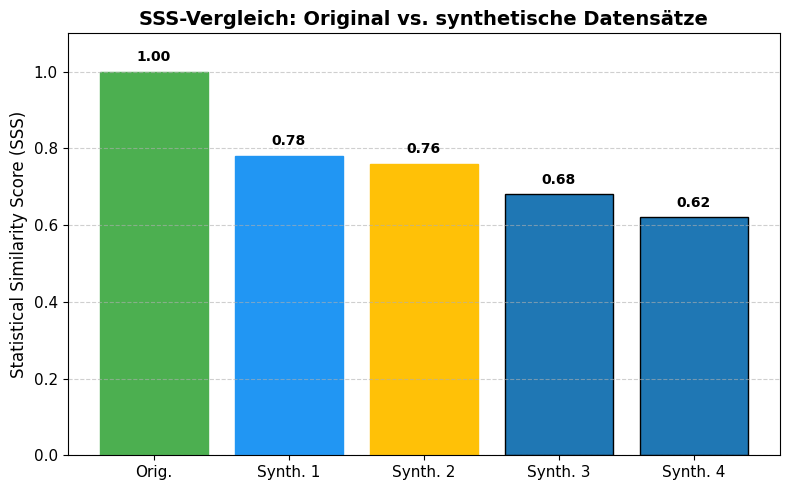

In [10]:
custom_weights = {
    'mean': 0.05,
    'median': 0.05,
    'variance': 0.05,
    'ks': 0.1,
    'chi2': 0.1,
    'wasserstein': 0.2,
    'mmd': 0.2,
    'kl': 0.2,
    'coverage': 0.05
}


result = compute_subscores(df_real, df_real, weights=custom_weights)
print("Statistical Similarity Score für originalen Datensatz:", result['SSS'])
result = compute_subscores(df_real, df_syn1, weights=custom_weights)
print("Statistical Similarity Score für synthetischen Datensatz 1:", result['SSS'])
result = compute_subscores(df_real, df_syn2, weights=custom_weights)
print("Statistical Similarity Score für synthetischen Datensatz 2:", result['SSS'])
""" result = compute_subscores(df_real, df_syn3, weights=custom_weights)
print("Statistical Similarity Score für synthetischen Datensatz 3:", result['SSS']) """



sss_scores = {
    "Orig.": 1.0,
    "Synth. 1": 0.78,
    "Synth. 2": 0.76,
    "Synth. 3": 0.68,
    "Synth. 4": 0.62,
}

plt.figure(figsize=(8, 5))
bars = plt.bar(sss_scores.keys(), sss_scores.values(), edgecolor='black')

# Farben anpassen
colors = ['#4CAF50', '#2196F3', '#FFC107']
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Werte über den Balken anzeigen
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.2f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Achsen und Titel gestalten
plt.ylabel("Statistical Similarity Score (SSS)", fontsize=12)
plt.title("SSS-Vergleich: Original vs. synthetische Datensätze", fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


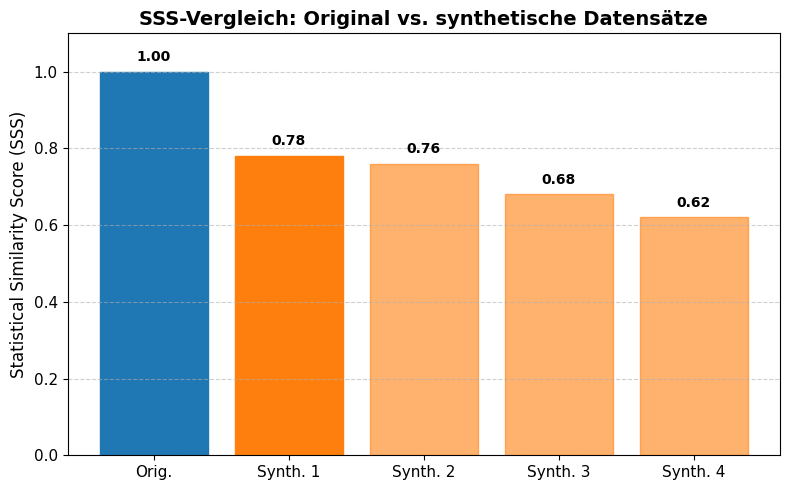

In [11]:
import matplotlib.pyplot as plt


sss_scores = {
    "Orig.": 1.0,
    "Synth. 1": 0.78,
    "Synth. 2": 0.76,
    "Synth. 3": 0.68,
    "Synth. 4": 0.62,
}


# Erstellen der Figur und der Achsen
plt.figure(figsize=(8, 5))

# Farben definieren
color_original = '#1f77b4'  # Blau für "Original"
color_synthetic = '#ff7f0e' # Orange für "Synthetisch"

# Balkendiagramm erstellen
bars = plt.bar(sss_scores.keys(), sss_scores.values(), edgecolor='black')

# Farbe für den "Original"-Balken (blau)
bars[0].set_color(color_original)

# Farbe für den ersten "Synthetisch"-Balken (dunkles Orange)
bars[1].set_color(color_synthetic)

# Farbe und Transparenz für die restlichen "Synthetisch"-Balken (blasses Orange)
for bar in bars[2:]:
    bar.set_color(color_synthetic)
    bar.set_alpha(0.6)  # Alpha-Wert für einen "blassen" Effekt

# Beschriftungen über den Balken hinzufügen
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.02, f"{yval:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Titel und Achsenbeschriftungen
plt.ylabel("Statistical Similarity Score (SSS)", fontsize=12)
plt.title("SSS-Vergleich: Original vs. synthetische Datensätze", fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# Diagramm anzeigen
plt.show()

 

